<a href="https://colab.research.google.com/github/shaestasaleem/flyrank-machine-learning-internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/shaestasaleem/flyrank-machine-learning-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

This playbook converts my validated Logistic Regression scores into a ranked queue for human editorial review.

The model does **not** determine that a page needs to be refreshed. Its target is whether clicks decline in the following seven-day outcome window. I therefore use the model score only as a directional signal for deciding which pages may deserve review first.

To keep the queue aligned with my validation design, I create grouped out-of-fold scores. Each row is scored by a model that was not trained on that row's client.

### Action policy

The action labels are practical queue-management rules, not new model predictions:

- **PRIORITY_REVIEW** — highest-ranked pages with enough recent exposure to justify earlier human review.
- **REVIEW_WITH_CAUTION** — highest-ranked pages with relatively low exposure, where the signal may be less stable.
- **WATCH** — elevated model score, but below the highest-priority band.
- **NO_IMMEDIATE_ACTION** — lower-ranked pages; no action from this model signal alone.

### Reason codes

Each row receives transparent reason codes:

- `HIGH_DECLINE_SCORE` — model score is in the highest score band.
- `ELEVATED_DECLINE_SCORE` — model score is elevated but below the highest band.
- `RECENT_CLICKS_DOWN` — recent seven-day clicks are lower than the previous seven-day period.
- `HIGH_EXPOSURE` — recent impressions are relatively high in the development population.
- `LOW_EXPOSURE_CAUTION` — recent impressions are relatively low, so the signal should be interpreted cautiously.
- `CTR_ABOVE_EXPECTED` — recent CTR is more than 1.20 times the expected CTR for the page's position bucket.
- `CONFLICTING_SIGNALS` — the model score is high even though recent clicks are stable or increasing.

These reason codes explain why a page appears in a review band. They do not establish that refreshing the page will improve performance.

The output is a **decision-support queue**: a higher rank means “review earlier,” not “automatically refresh.”

In [2]:
# ============================================================
# ML-10 — Content Action Playbook
# Section 1: Ranked actions + reason codes
# ============================================================

%pip -q install duckdb huggingface_hub pandas numpy scikit-learn

import duckdb
import numpy as np
import pandas as pd
import sklearn

from google.colab import userdata
from IPython.display import display

from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score


RANDOM_SEED = 42
N_SPLITS = 5

TARGET = "future_click_decline"

BASE_FEATURES = [
    "recent_impressions_7d",
    "recent_clicks_7d",
    "recent_ctr",
    "recent_avg_position",
    "pre_decision_click_change_7d",
]

FEATURES = BASE_FEATURES + ["ctr_vs_expected"]


# ------------------------------------------------------------
# Connect to FlyRank warehouse
# ------------------------------------------------------------

hf_token = userdata.get("HF_TOKEN")

if not hf_token:
    raise ValueError(
        "HF_TOKEN not found. Add it in Colab Secrets "
        "and enable notebook access."
    )

con = duckdb.connect()

con.execute("INSTALL httpfs;")
con.execute("LOAD httpfs;")

safe_token = hf_token.replace("'", "''")

con.execute(f"""
CREATE OR REPLACE SECRET hf_token (
    TYPE HUGGINGFACE,
    TOKEN '{safe_token}'
);
""")

WAREHOUSE = "hf://datasets/FlyRank/internship-warehouse"

MARCH_DAILY = (
    f"{WAREHOUSE}/fact_content_daily_performance/"
    "month=2026-03/data_0.parquet"
)

print("Warehouse connection ready.")
print("Development month: March 2026")
print("June 2026 remains sealed.")
print("Random seed:", RANDOM_SEED)
print("scikit-learn:", sklearn.__version__)


# ------------------------------------------------------------
# Rebuild the validated development frame
# ------------------------------------------------------------

signal_frame = con.sql(f"""
WITH daily AS (
    SELECT
        report_date,
        client_hash_id,
        content_hash_id,
        gsc_impressions,
        gsc_clicks,
        gsc_sum_position
    FROM read_parquet('{MARCH_DAILY}')
    WHERE gsc_data_available IS TRUE
),

windows AS (
    SELECT
        client_hash_id,
        content_hash_id,

        COUNT(DISTINCT report_date) AS available_days,

        SUM(
            CASE
                WHEN report_date BETWEEN DATE '2026-03-11'
                                     AND DATE '2026-03-17'
                THEN COALESCE(gsc_impressions, 0)
                ELSE 0
            END
        ) AS previous_impressions_7d,

        SUM(
            CASE
                WHEN report_date BETWEEN DATE '2026-03-11'
                                     AND DATE '2026-03-17'
                THEN COALESCE(gsc_clicks, 0)
                ELSE 0
            END
        ) AS previous_clicks_7d,

        SUM(
            CASE
                WHEN report_date BETWEEN DATE '2026-03-18'
                                     AND DATE '2026-03-24'
                THEN COALESCE(gsc_impressions, 0)
                ELSE 0
            END
        ) AS recent_impressions_7d,

        SUM(
            CASE
                WHEN report_date BETWEEN DATE '2026-03-18'
                                     AND DATE '2026-03-24'
                THEN COALESCE(gsc_clicks, 0)
                ELSE 0
            END
        ) AS recent_clicks_7d,

        SUM(
            CASE
                WHEN report_date BETWEEN DATE '2026-03-18'
                                     AND DATE '2026-03-24'
                THEN COALESCE(gsc_sum_position, 0)
                ELSE 0
            END
        ) AS recent_sum_position_7d,

        SUM(
            CASE
                WHEN report_date BETWEEN DATE '2026-03-25'
                                     AND DATE '2026-03-31'
                THEN COALESCE(gsc_clicks, 0)
                ELSE 0
            END
        ) AS future_clicks_7d

    FROM daily

    GROUP BY
        client_hash_id,
        content_hash_id
)

SELECT *
FROM windows

WHERE available_days = 31
  AND previous_impressions_7d > 0
  AND recent_impressions_7d > 0
""").df()


# ------------------------------------------------------------
# Decision-time features
# ------------------------------------------------------------

signal_frame["recent_ctr"] = (
    signal_frame["recent_clicks_7d"]
    / signal_frame["recent_impressions_7d"]
)

signal_frame["recent_avg_position"] = (
    signal_frame["recent_sum_position_7d"]
    / signal_frame["recent_impressions_7d"]
)

signal_frame["pre_decision_click_change_7d"] = (
    signal_frame["recent_clicks_7d"]
    - signal_frame["previous_clicks_7d"]
)

# Outcome only — never used as a reason code.
signal_frame[TARGET] = (
    signal_frame["future_clicks_7d"]
    < signal_frame["recent_clicks_7d"]
).astype(int)


# Same clean population used in the validated model
model_frame = signal_frame[
    (signal_frame["recent_impressions_7d"] >= 20)
    & (signal_frame["recent_clicks_7d"] > 0)
].copy()


model_frame["position_bucket"] = pd.cut(
    model_frame["recent_avg_position"],
    bins=[0, 3, 10, 20, np.inf],
    labels=["1-3", "4-10", "11-20", "20+"],
    include_lowest=True
)


print("\nDevelopment rows:", f"{len(model_frame):,}")
print(
    "Observed future-decline base rate:",
    round(model_frame[TARGET].mean(), 4)
)


# ------------------------------------------------------------
# Grouped out-of-fold scores
# ------------------------------------------------------------

gkf = GroupKFold(n_splits=N_SPLITS)

oof_parts = []

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(
        model_frame,
        y=model_frame[TARGET],
        groups=model_frame["client_hash_id"]
    ),
    start=1
):

    train_df = model_frame.iloc[train_idx].copy()
    test_df = model_frame.iloc[test_idx].copy()

    # Expected CTR is learned from training clients only.
    expected_ctr_by_position = (
        train_df
        .groupby(
            "position_bucket",
            observed=True
        )["recent_ctr"]
        .median()
    )

    fallback_ctr = train_df["recent_ctr"].median()

    train_df["expected_ctr_for_position"] = (
        train_df["position_bucket"]
        .map(expected_ctr_by_position)
        .astype(float)
        .fillna(fallback_ctr)
    )

    test_df["expected_ctr_for_position"] = (
        test_df["position_bucket"]
        .map(expected_ctr_by_position)
        .astype(float)
        .fillna(fallback_ctr)
    )

    train_df["ctr_vs_expected"] = (
        train_df["recent_ctr"]
        / train_df["expected_ctr_for_position"].replace(0, np.nan)
    )

    test_df["ctr_vs_expected"] = (
        test_df["recent_ctr"]
        / test_df["expected_ctr_for_position"].replace(0, np.nan)
    )

    assert not train_df[FEATURES].isna().any().any()
    assert not test_df[FEATURES].isna().any().any()

    model = Pipeline([
        ("scale", StandardScaler()),
        (
            "logistic",
            LogisticRegression(
                max_iter=2000,
                random_state=RANDOM_SEED
            )
        )
    ])

    model.fit(
        train_df[FEATURES],
        train_df[TARGET]
    )

    test_df["model_score"] = model.predict_proba(
        test_df[FEATURES]
    )[:, 1]

    test_df["fold"] = fold

    oof_parts.append(test_df)


oof = pd.concat(
    oof_parts,
    ignore_index=True
)

assert len(oof) == len(model_frame)

print(
    "\nGrouped out-of-fold rows:",
    f"{len(oof):,}"
)

print(
    "Grouped OOF ROC-AUC:",
    round(
        roc_auc_score(
            oof[TARGET],
            oof["model_score"]
        ),
        4
    )
)


# ------------------------------------------------------------
# Queue-management thresholds
# ------------------------------------------------------------
# These are operational heuristics, not learned truths.

HIGH_SCORE_THRESHOLD = (
    oof["model_score"].quantile(0.95)
)

ELEVATED_SCORE_THRESHOLD = (
    oof["model_score"].quantile(0.80)
)

LOW_EXPOSURE_THRESHOLD = (
    oof["recent_impressions_7d"].quantile(0.25)
)

HIGH_EXPOSURE_THRESHOLD = (
    oof["recent_impressions_7d"].quantile(0.75)
)


print("\nPlaybook thresholds")

print(
    "Top 5% model-score threshold:",
    round(HIGH_SCORE_THRESHOLD, 4)
)

print(
    "Top 20% model-score threshold:",
    round(ELEVATED_SCORE_THRESHOLD, 4)
)

print(
    "Low-exposure threshold (Q1 impressions):",
    round(LOW_EXPOSURE_THRESHOLD, 2)
)

print(
    "High-exposure threshold (Q3 impressions):",
    round(HIGH_EXPOSURE_THRESHOLD, 2)
)


# ------------------------------------------------------------
# Reason codes
# ------------------------------------------------------------

def build_reason_codes(row):

    reasons = []

    if row["model_score"] >= HIGH_SCORE_THRESHOLD:
        reasons.append("HIGH_DECLINE_SCORE")

    elif row["model_score"] >= ELEVATED_SCORE_THRESHOLD:
        reasons.append("ELEVATED_DECLINE_SCORE")

    if row["pre_decision_click_change_7d"] < 0:
        reasons.append("RECENT_CLICKS_DOWN")

    if row["recent_impressions_7d"] >= HIGH_EXPOSURE_THRESHOLD:
        reasons.append("HIGH_EXPOSURE")

    if row["recent_impressions_7d"] <= LOW_EXPOSURE_THRESHOLD:
        reasons.append("LOW_EXPOSURE_CAUTION")

    if row["ctr_vs_expected"] > 1.20:
        reasons.append("CTR_ABOVE_EXPECTED")

    if (
        row["model_score"] >= HIGH_SCORE_THRESHOLD
        and row["pre_decision_click_change_7d"] >= 0
    ):
        reasons.append("CONFLICTING_SIGNALS")

    if not reasons:
        reasons.append("NO_STRONG_SIGNAL")

    return ";".join(reasons)


oof["reason_codes"] = oof.apply(
    build_reason_codes,
    axis=1
)


# ------------------------------------------------------------
# Action mapping
# ------------------------------------------------------------

def assign_action(row):

    if (
        row["model_score"] >= HIGH_SCORE_THRESHOLD
        and row["recent_impressions_7d"] <= LOW_EXPOSURE_THRESHOLD
    ):
        return "REVIEW_WITH_CAUTION"

    if row["model_score"] >= HIGH_SCORE_THRESHOLD:
        return "PRIORITY_REVIEW"

    if row["model_score"] >= ELEVATED_SCORE_THRESHOLD:
        return "WATCH"

    return "NO_IMMEDIATE_ACTION"


oof["action"] = oof.apply(
    assign_action,
    axis=1
)


# ------------------------------------------------------------
# Ranked queue
# ------------------------------------------------------------

ranked_queue = (
    oof
    .sort_values(
        "model_score",
        ascending=False
    )
    .reset_index(drop=True)
    .copy()
)

ranked_queue["rank"] = (
    np.arange(1, len(ranked_queue) + 1)
)


queue_columns = [
    "rank",
    "client_hash_id",
    "content_hash_id",
    "action",
    "reason_codes",
    "model_score",
    "recent_impressions_7d",
    "recent_clicks_7d",
    "recent_ctr",
    "recent_avg_position",
    "pre_decision_click_change_7d",
    "ctr_vs_expected",
    "fold"
]

ranked_queue = ranked_queue[queue_columns]


# ------------------------------------------------------------
# Public-safe preview
# Never display client/content hashes in the notebook output.
# ------------------------------------------------------------

public_preview = ranked_queue[
    [
        "rank",
        "action",
        "reason_codes",
        "model_score",
        "recent_impressions_7d",
        "recent_clicks_7d",
        "recent_ctr",
        "recent_avg_position",
        "pre_decision_click_change_7d",
        "ctr_vs_expected"
    ]
].head(20)


print("\nTop 20 public-safe queue preview")
display(public_preview.round(4))


# ------------------------------------------------------------
# Action distribution
# ------------------------------------------------------------

action_summary = (
    ranked_queue["action"]
    .value_counts()
    .rename_axis("action")
    .reset_index(name="rows")
)

action_summary["share"] = (
    action_summary["rows"]
    / len(ranked_queue)
)

print("\nAction distribution")
display(action_summary.round(4))


# ------------------------------------------------------------
# Archetype -> action map
# ------------------------------------------------------------

archetype_action_map = pd.DataFrame([
    {
        "archetype": "Highest score + adequate exposure",
        "action": "PRIORITY_REVIEW",
        "interpretation":
            "Review earlier; the model flags elevated decline risk."
    },
    {
        "archetype": "Highest score + low exposure",
        "action": "REVIEW_WITH_CAUTION",
        "interpretation":
            "Inspect manually because limited exposure may make the signal less stable."
    },
    {
        "archetype": "Elevated score below highest band",
        "action": "WATCH",
        "interpretation":
            "Monitor and review if other editorial signals agree."
    },
    {
        "archetype": "Lower-ranked score",
        "action": "NO_IMMEDIATE_ACTION",
        "interpretation":
            "No action from this model signal alone."
    },
    {
        "archetype": "High score + stable/increasing recent clicks",
        "action": "HUMAN_CONTEXT_CHECK",
        "interpretation":
            "Signals conflict, so context should be checked before acting."
    }
])


print("\nArchetype-to-action mapping")
display(archetype_action_map)

Warehouse connection ready.
Development month: March 2026
June 2026 remains sealed.
Random seed: 42
scikit-learn: 1.6.1


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Development rows: 27,186
Observed future-decline base rate: 0.5504

Grouped out-of-fold rows: 27,186
Grouped OOF ROC-AUC: 0.6477

Playbook thresholds
Top 5% model-score threshold: 0.8125
Top 20% model-score threshold: 0.6595
Low-exposure threshold (Q1 impressions): 327.0
High-exposure threshold (Q3 impressions): 1656.0

Top 20 public-safe queue preview


,rank,action,reason_codes,model_score,recent_impressions_7d,recent_clicks_7d,recent_ctr,recent_avg_position,pre_decision_click_change_7d,ctr_vs_expected
0,1,PRIORITY_REVIEW,HIGH_DECLINE_SCORE;HIGH_EXPOSURE;CTR_ABOVE_EXP...,1.0000,29010.0,280.0,0.0097,3.5051,186.0,2.7170
1,2,PRIORITY_REVIEW,HIGH_DECLINE_SCORE;HIGH_EXPOSURE;CTR_ABOVE_EXP...,1.0000,52735.0,710.0,0.0135,4.2404,219.0,3.7900
2,3,REVIEW_WITH_CAUTION,HIGH_DECLINE_SCORE;LOW_EXPOSURE_CAUTION;CTR_AB...,1.0000,41.0,5.0,0.1220,4.3659,0.0,34.3293
3,4,PRIORITY_REVIEW,HIGH_DECLINE_SCORE;HIGH_EXPOSURE;CTR_ABOVE_EXP...,1.0000,12336.0,286.0,0.0232,5.4560,117.0,6.5263
4,5,REVIEW_WITH_CAUTION,HIGH_DECLINE_SCORE;LOW_EXPOSURE_CAUTION;CTR_AB...,1.0000,40.0,4.0,0.1000,5.3000,4.0,28.1500
5,6,REVIEW_WITH_CAUTION,HIGH_DECLINE_SCORE;RECENT_CLICKS_DOWN;LOW_EXPO...,0.9999,91.0,9.0,0.0989,3.4505,-2.0,27.8407
6,7,REVIEW_WITH_CAUTION,HIGH_DECLINE_SCORE;LOW_EXPOSURE_CAUTION;CTR_AB...,0.9998,64.0,6.0,0.0938,3.6406,1.0,25.1250
7,8,REVIEW_WITH_CAUTION,HIGH_DECLINE_SCORE;RECENT_CLICKS_DOWN;LOW_EXPO...,0.9998,42.0,3.0,0.0714,39.9048,-2.0,31.3571
8,9,REVIEW_WITH_CAUTION,HIGH_DECLINE_SCORE;RECENT_CLICKS_DOWN;LOW_EXPO...,0.9998,79.0,7.0,0.0886,7.6582,-1.0,24.9430
9,10,REVIEW_WITH_CAUTION,HIGH_DECLINE_SCORE;LOW_EXPOSURE_CAUTION;CTR_AB...,0.9998,69.0,6.0,0.0870,5.4638,0.0,24.4783



Action distribution


,action,rows,share
0,NO_IMMEDIATE_ACTION,21748,0.8000
1,WATCH,4078,0.1500
2,REVIEW_WITH_CAUTION,1032,0.0380
3,PRIORITY_REVIEW,328,0.0121



Archetype-to-action mapping


,archetype,action,interpretation
0,Highest score + adequate exposure,PRIORITY_REVIEW,Review earlier; the model flags elevated decli...
1,Highest score + low exposure,REVIEW_WITH_CAUTION,Inspect manually because limited exposure may ...
2,Elevated score below highest band,WATCH,Monitor and review if other editorial signals ...
3,Lower-ranked score,NO_IMMEDIATE_ACTION,No action from this model signal alone.
4,High score + stable/increasing recent clicks,HUMAN_CONTEXT_CHECK,"Signals conflict, so context should be checked..."


### Section 1 interpretation

The playbook keeps the action queue intentionally narrow.

The top 5% model-score threshold is 0.8125. Within this highest score band, 328 rows are assigned to `PRIORITY_REVIEW` and 1,032 are assigned to `REVIEW_WITH_CAUTION`. The caution group is larger because many high-scoring rows have relatively low recent exposure.

Overall, 80% of rows receive `NO_IMMEDIATE_ACTION`, 15% are placed in `WATCH`, 3.8% in `REVIEW_WITH_CAUTION`, and 1.21% in `PRIORITY_REVIEW`.

The top-ranked preview also shows why human interpretation matters. Several high-scoring observations have low impression counts together with very large `ctr_vs_expected` ratios. These cases may be informative, but the ratio can become extreme when the underlying exposure is small.

For that reason, I do not treat the highest model score as an automatic refresh recommendation. The playbook separates high-score, adequate-exposure cases from high-score, low-exposure cases so that the latter receive additional human scrutiny.

The action bands are operational review rules rather than learned truths. Their purpose is to make the validated ranking usable while preserving the uncertainty visible in the data.

## 2. Intended use and limits

### Intended use

This playbook is designed to help a human content or editorial reviewer decide which pages to inspect first when review capacity is limited.

The ranked queue uses a validated model score together with transparent decision-time signals such as recent clicks, impressions, CTR, position, and recent click direction.

The intended workflow is:

1. Use the queue to prioritize review.
2. Read the reason codes explaining why an item was surfaced.
3. Inspect the page and its wider business, search, and editorial context.
4. Decide whether to monitor, investigate, update, or take no action.

The model is therefore a **directional decision-support tool**, not an autonomous content-management system.

### Decay / refresh insight

The target measures whether clicks declined in the following seven-day outcome window.

A high score can therefore be interpreted as a signal that the page looked more likely to experience near-term click decline in this March development experiment.

It does **not** measure whether refreshing the content would improve performance.

The playbook can support a decision about which pages may be worth reviewing for possible decay, but it cannot establish that a refresh is necessary or that a refresh would cause clicks or impressions to improve.

### Limits

This playbook currently has several important limits:

- The analysis is based on the March 2026 development period.
- The model was validated using grouped client folds, but performance varied across held-out client groups.
- The evaluated population contains only rows that passed the modeling filters.
- The population requires full-month availability, so it is not a completely decision-time-defined population.
- Low-exposure observations can produce unstable ratios and extreme scores.
- The model predicts a proxy outcome: future click decline. It does not directly predict content quality, business value, or refresh effectiveness.
- External changes such as search demand, seasonality, ranking changes, competition, or business priorities may explain a decline without implying that the page itself needs editing.
- The recommendations remain development-stage and non-production.

### Cost and value

The queue is useful because editorial review has a cost.

A false positive may spend human review time on a page that would not have declined. A false negative may leave a genuinely declining page lower in the queue.

For this reason, the playbook does not recommend reviewing every page. It concentrates attention on a smaller high-score group while preserving a `WATCH` category for less certain cases.

The value of the model is therefore not automatic action. Its potential value is helping a human reviewer spend limited attention more selectively.


In [3]:
# ============================================================
# Section 2 — Intended use and limits
# ============================================================

# Summarize how much of the development population
# each action would send toward human attention.

total_rows = len(ranked_queue)

priority_rows = (
    ranked_queue["action"] == "PRIORITY_REVIEW"
).sum()

caution_rows = (
    ranked_queue["action"] == "REVIEW_WITH_CAUTION"
).sum()

watch_rows = (
    ranked_queue["action"] == "WATCH"
).sum()

no_action_rows = (
    ranked_queue["action"] == "NO_IMMEDIATE_ACTION"
).sum()

review_now_rows = priority_rows + caution_rows

use_summary = pd.DataFrame([
    {
        "queue_stage": "Priority human review",
        "rows": priority_rows,
        "share": priority_rows / total_rows,
        "intended_use":
            "Review earlier; enough exposure for the highest score band."
    },
    {
        "queue_stage": "Review with caution",
        "rows": caution_rows,
        "share": caution_rows / total_rows,
        "intended_use":
            "Human review with extra caution because exposure is relatively low."
    },
    {
        "queue_stage": "Watch",
        "rows": watch_rows,
        "share": watch_rows / total_rows,
        "intended_use":
            "Monitor; do not act from the model score alone."
    },
    {
        "queue_stage": "No immediate action",
        "rows": no_action_rows,
        "share": no_action_rows / total_rows,
        "intended_use":
            "No action from this model signal alone."
    }
])

print("Intended-use workload")
display(use_summary.round(4))


print(
    "\nRows surfaced for immediate human review:",
    f"{review_now_rows:,}"
)

print(
    "Share surfaced for immediate human review:",
    f"{review_now_rows / total_rows:.2%}"
)


# ------------------------------------------------------------
# Explicit scope / limitation table
# ------------------------------------------------------------

scope_limits = pd.DataFrame([
    {
        "item": "Development period",
        "status": "LIMIT",
        "note": "Results are based on March 2026 development data."
    },
    {
        "item": "Prediction target",
        "status": "LIMIT",
        "note": (
            "Target is next-7-day click decline, not whether "
            "a refresh will improve performance."
        )
    },
    {
        "item": "Client generalization",
        "status": "VALIDATED WITH CAUTION",
        "note": (
            "Grouped client validation was used, but results "
            "varied across held-out client groups."
        )
    },
    {
        "item": "Low exposure",
        "status": "CAUTION",
        "note": (
            "Low impression counts can create unstable ratios "
            "and extreme model scores."
        )
    },
    {
        "item": "Population selection",
        "status": "LIMIT",
        "note": (
            "The evaluation population requires full-month "
            "availability."
        )
    },
    {
        "item": "Automation",
        "status": "NOT SUPPORTED",
        "note": (
            "The model supports prioritization for human review; "
            "it does not support automatic content changes."
        )
    }
])

print("\nPlaybook scope and limits")
display(scope_limits)


Intended-use workload


,queue_stage,rows,share,intended_use
0,Priority human review,328,0.0121,Review earlier; enough exposure for the highes...
1,Review with caution,1032,0.0380,Human review with extra caution because exposu...
2,Watch,4078,0.1500,Monitor; do not act from the model score alone.
3,No immediate action,21748,0.8000,No action from this model signal alone.



Rows surfaced for immediate human review: 1,360
Share surfaced for immediate human review: 5.00%

Playbook scope and limits


,item,status,note
0,Development period,LIMIT,Results are based on March 2026 development data.
1,Prediction target,LIMIT,"Target is next-7-day click decline, not whethe..."
2,Client generalization,VALIDATED WITH CAUTION,"Grouped client validation was used, but result..."
3,Low exposure,CAUTION,Low impression counts can create unstable rati...
4,Population selection,LIMIT,The evaluation population requires full-month ...
5,Automation,NOT SUPPORTED,The model supports prioritization for human re...


## 3. Human review + the no-go list

The ranked queue is a starting point for human review, not a final content decision.

Before taking action on a surfaced page, a reviewer should check the context that is not represented fully by the model.

### Human review rules

For every `PRIORITY_REVIEW` or `REVIEW_WITH_CAUTION` item, the reviewer should check:

1. **Is the decline signal meaningful?**  
   Look at the recent traffic pattern and confirm that the change is not based on only a small amount of activity.

2. **Is search demand changing?**  
   A decline may reflect seasonality or lower search demand rather than a problem with the page.

3. **Has ranking or visibility changed?**  
   Review impressions, CTR, and average position together rather than interpreting one metric alone.

4. **Is the content actually outdated or incomplete?**  
   The model does not read the page and cannot determine whether the information needs updating.

5. **Is the page important enough to spend editorial time on?**  
   Business importance and editorial priorities are outside the current model.

6. **Are signals conflicting?**  
   A high model score together with stable or increasing recent clicks should trigger additional context review rather than immediate action.

7. **Is exposure sufficient?**  
   Items carrying `LOW_EXPOSURE_CAUTION` require more skepticism because ratios can become extreme when impression and click counts are small.

### Human decision after review

A reviewer may choose:

- **Investigate / refresh candidate** — there is additional evidence that the page deserves editorial attention.
- **Monitor** — the signal is interesting but there is not enough evidence to act yet.
- **No action** — contextual review does not support intervention.
- **Escalate for specialist review** — the page requires SEO, editorial, product, or business context not available in the model.

The model score should remain visible as supporting evidence, but the final action should come from human judgment.

### What should NOT be automated

This playbook should not automatically:

- rewrite page content;
- publish or update content;
- change titles, headings, metadata, or URLs;
- delete, redirect, or unpublish pages;
- label a page as definitively “bad” or “decayed”;
- state that a page definitely needs refreshing;
- assume that refreshing a page will increase clicks or impressions;
- allocate editorial resources without human review;
- act on low-exposure observations without additional context;
- use private identifiers as an explanation to reviewers.

The current evidence supports **ranking and decision-support**, not autonomous editorial action.

### Why human review remains necessary

The model target is an observed future click decline, not content quality and not the causal effect of a refresh.

A model can therefore correctly flag a higher-risk page while still being unable to explain whether the cause is content age, search demand, ranking movement, seasonality, competition, or another factor.

Human review supplies this missing context.

In [4]:
# ============================================================
# Section 3 — Human review + the no-go list
# ============================================================

# ------------------------------------------------------------
# Human-review checklist
# ------------------------------------------------------------

human_review_rules = pd.DataFrame([
    {
        "check": "Traffic context",
        "reviewer_question":
            "Is the observed change meaningful, or is activity too small/noisy?",
        "why_needed":
            "Low counts can make ratios and short-term changes unstable."
    },
    {
        "check": "Search demand",
        "reviewer_question":
            "Could seasonality or changing search demand explain the pattern?",
        "why_needed":
            "The model does not observe the full external demand context."
    },
    {
        "check": "Visibility",
        "reviewer_question":
            "Did impressions, CTR, or average position change together?",
        "why_needed":
            "A click decline can have multiple search-performance explanations."
    },
    {
        "check": "Content condition",
        "reviewer_question":
            "Is the page actually outdated, incomplete, or no longer relevant?",
        "why_needed":
            "The current model does not read or judge page content quality."
    },
    {
        "check": "Business importance",
        "reviewer_question":
            "Is this page important enough to justify editorial effort?",
        "why_needed":
            "Business value is not part of the current prediction target."
    },
    {
        "check": "Conflicting signals",
        "reviewer_question":
            "Does a high score conflict with stable or increasing recent clicks?",
        "why_needed":
            "Conflicting evidence should be investigated before acting."
    },
    {
        "check": "Exposure",
        "reviewer_question":
            "Does the item carry LOW_EXPOSURE_CAUTION?",
        "why_needed":
            "Low-exposure observations require additional skepticism."
    }
])

print("Human-review checklist")
display(human_review_rules)


# ------------------------------------------------------------
# No-go list
# ------------------------------------------------------------

no_go_actions = pd.DataFrame([
    {
        "automated_action": "Rewrite page content",
        "allowed": False,
        "reason":
            "The model ranks decline risk; it does not generate validated edits."
    },
    {
        "automated_action": "Publish content changes",
        "allowed": False,
        "reason":
            "Publishing requires human editorial approval."
    },
    {
        "automated_action": "Change title / metadata / URL",
        "allowed": False,
        "reason":
            "The model does not establish which specific page element caused the signal."
    },
    {
        "automated_action": "Delete / redirect / unpublish",
        "allowed": False,
        "reason":
            "The model is not designed for destructive content decisions."
    },
    {
        "automated_action": "Automatically declare refresh required",
        "allowed": False,
        "reason":
            "Future click decline is not equivalent to proven refresh need."
    },
    {
        "automated_action": "Claim refresh will improve performance",
        "allowed": False,
        "reason":
            "No causal refresh experiment is represented by this model."
    },
    {
        "automated_action": "Allocate editorial resources automatically",
        "allowed": False,
        "reason":
            "Cost, business value, and editorial priorities require human context."
    }
])

print("\nNo-go automation list")
display(no_go_actions)


# ------------------------------------------------------------
# Audit the immediate-review pool
# ------------------------------------------------------------

review_pool = ranked_queue[
    ranked_queue["action"].isin(
        ["PRIORITY_REVIEW", "REVIEW_WITH_CAUTION"]
    )
].copy()


review_pool["has_low_exposure_caution"] = (
    review_pool["reason_codes"]
    .str.contains("LOW_EXPOSURE_CAUTION", regex=False)
)

review_pool["has_conflicting_signals"] = (
    review_pool["reason_codes"]
    .str.contains("CONFLICTING_SIGNALS", regex=False)
)

review_pool["recent_clicks_down"] = (
    review_pool["reason_codes"]
    .str.contains("RECENT_CLICKS_DOWN", regex=False)
)


human_review_summary = pd.DataFrame([
    {
        "review_condition": "Immediate review pool",
        "rows": len(review_pool),
        "share_of_review_pool": 1.0
    },
    {
        "review_condition": "Low-exposure caution",
        "rows": int(
            review_pool["has_low_exposure_caution"].sum()
        ),
        "share_of_review_pool":
            review_pool["has_low_exposure_caution"].mean()
    },
    {
        "review_condition": "Conflicting signals",
        "rows": int(
            review_pool["has_conflicting_signals"].sum()
        ),
        "share_of_review_pool":
            review_pool["has_conflicting_signals"].mean()
    },
    {
        "review_condition": "Recent clicks down",
        "rows": int(
            review_pool["recent_clicks_down"].sum()
        ),
        "share_of_review_pool":
            review_pool["recent_clicks_down"].mean()
    }
])

print("\nWhy human review is needed in the surfaced queue")
display(human_review_summary.round(4))


# ------------------------------------------------------------
# Safety assertions
# ------------------------------------------------------------

assert no_go_actions["allowed"].eq(False).all()

assert len(review_pool) == 1360, (
    "Review-pool size changed from the Section 2 result. "
    "Recheck the action policy before continuing."
)

print(
    "\nPASS: the playbook keeps content actions "
    "human-reviewed and non-automatic."
)

Human-review checklist


,check,reviewer_question,why_needed
0,Traffic context,"Is the observed change meaningful, or is activ...",Low counts can make ratios and short-term chan...
1,Search demand,Could seasonality or changing search demand ex...,The model does not observe the full external d...
2,Visibility,"Did impressions, CTR, or average position chan...",A click decline can have multiple search-perfo...
3,Content condition,"Is the page actually outdated, incomplete, or ...",The current model does not read or judge page ...
4,Business importance,Is this page important enough to justify edito...,Business value is not part of the current pred...
5,Conflicting signals,Does a high score conflict with stable or incr...,Conflicting evidence should be investigated be...
6,Exposure,Does the item carry LOW_EXPOSURE_CAUTION?,Low-exposure observations require additional s...



No-go automation list


,automated_action,allowed,reason
0,Rewrite page content,False,The model ranks decline risk; it does not gene...
1,Publish content changes,False,Publishing requires human editorial approval.
2,Change title / metadata / URL,False,The model does not establish which specific pa...
3,Delete / redirect / unpublish,False,The model is not designed for destructive cont...
4,Automatically declare refresh required,False,Future click decline is not equivalent to prov...
5,Claim refresh will improve performance,False,No causal refresh experiment is represented by...
6,Allocate editorial resources automatically,False,"Cost, business value, and editorial priorities..."



Why human review is needed in the surfaced queue


,review_condition,rows,share_of_review_pool
0,Immediate review pool,1360,1.0000
1,Low-exposure caution,1032,0.7588
2,Conflicting signals,1295,0.9522
3,Recent clicks down,65,0.0478



PASS: the playbook keeps content actions human-reviewed and non-automatic.


### Section 3 interpretation

The surfaced queue reinforces the need for human review.

Of the 1,360 rows surfaced for immediate review, 1,032 (75.88%) carry the `LOW_EXPOSURE_CAUTION` flag. This means much of the high-score queue contains relatively limited recent exposure, where ratios and short-term signals may be less stable.

I also observed that 1,295 rows (95.22%) carry `CONFLICTING_SIGNALS`: they receive a high model score even though recent clicks are stable or increasing. Only 65 rows (4.78%) in the immediate-review pool show recent clicks declining.

This does not mean the high model scores are automatically wrong. The Logistic Regression combines several features, so a high score can arise from other patterns. However, it shows why the model score should not be translated directly into a refresh action.

The human reviewer should inspect traffic context, visibility, content condition, business importance, exposure, and conflicting signals before taking any editorial action.

I therefore keep the playbook as a prioritization and decision-support system rather than an automated content-management workflow.

## 4. Monitoring / retrain triggers


A recommendation system can become stale even if its original validation was reasonable.

I would therefore monitor both model performance and the distribution of the queue.

### What I would monitor

When future outcomes are available:

- future-decline base rate;
- ROC-AUC;
- Precision@20 and Precision@50;
- performance across different client groups.

Even before future labels are available:

- model-score distribution;
- share of rows entering each action band;
- recent-impression distribution;
- proportion of recommendations carrying `LOW_EXPOSURE_CAUTION`;
- proportion carrying `CONFLICTING_SIGNALS`;
- missing or changed feature definitions.

### When I would revalidate or consider retraining

I would trigger investigation when:

1. **Ranking performance weakens materially.**  
   If Precision@K or ROC-AUC becomes meaningfully weaker than the March development reference, I would revalidate before continuing to trust the ranking.

2. **The outcome base rate changes materially.**  
   A different prevalence of future click decline may indicate that the operating environment has changed.

3. **The score or action distribution shifts substantially.**  
   For example, if a much larger share of pages suddenly enters `PRIORITY_REVIEW`, I would check for data or model drift before increasing editorial workload.

4. **Client-level performance becomes unstable.**  
   The grouped validation already showed variation across held-out clients, so new client patterns should be treated as a reason for additional validation.

5. **Feature definitions or data collection change.**  
   Changes to GSC availability, time windows, position calculations, or other inputs require revalidation even if headline metrics initially look similar.

6. **The review queue becomes dominated by caution flags.**  
   A high share of low-exposure or conflicting-signal cases may mean the current features or action rules are no longer producing a useful editorial queue.

7. **A newer representative time period becomes available.**  
   The current playbook is based on March 2026 development data, so later periods should be used to test whether the observed ranking behavior persists.

### Trigger philosophy

These are monitoring signals, not automatic retraining commands.

I would first investigate the cause of a change, check data quality, and rerun validation. Retraining should happen only when there is evidence that the existing model or feature relationships no longer provide useful decision-support.

I do not treat a single bad week or one unusual client as sufficient evidence to retrain.

In [5]:
# ============================================================
# Section 4 — Monitoring / retrain triggers
# ============================================================

from sklearn.metrics import roc_auc_score


# ------------------------------------------------------------
# Ranking metric helper
# ------------------------------------------------------------

def precision_at_k(y_true, scores, k):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    if len(y_true) < k:
        return np.nan

    top_idx = np.argsort(scores)[::-1][:k]
    return y_true[top_idx].mean()


# ------------------------------------------------------------
# March development reference values
# ------------------------------------------------------------

march_base_rate = oof[TARGET].mean()

march_p20 = precision_at_k(
    oof[TARGET],
    oof["model_score"],
    20
)

march_p50 = precision_at_k(
    oof[TARGET],
    oof["model_score"],
    50
)

march_auc = roc_auc_score(
    oof[TARGET],
    oof["model_score"]
)

march_score_median = oof["model_score"].median()

priority_share = (
    ranked_queue["action"]
    .eq("PRIORITY_REVIEW")
    .mean()
)

immediate_review_share = (
    ranked_queue["action"]
    .isin(
        ["PRIORITY_REVIEW", "REVIEW_WITH_CAUTION"]
    )
    .mean()
)

low_exposure_share = (
    review_pool["has_low_exposure_caution"].mean()
)

conflicting_signal_share = (
    review_pool["has_conflicting_signals"].mean()
)


monitoring_baseline = pd.DataFrame([
    {
        "metric": "Future-decline base rate",
        "march_reference": march_base_rate,
        "why_monitor":
            "Large outcome shifts may indicate a different operating environment."
    },
    {
        "metric": "Grouped OOF Precision@20",
        "march_reference": march_p20,
        "why_monitor":
            "Measures relevance at the very top of the review queue."
    },
    {
        "metric": "Grouped OOF Precision@50",
        "march_reference": march_p50,
        "why_monitor":
            "Measures relevance across a slightly larger review budget."
    },
    {
        "metric": "Grouped pooled OOF ROC-AUC",
        "march_reference": march_auc,
        "why_monitor":
            "Tracks broader ranking discrimination."
    },
    {
        "metric": "Median model score",
        "march_reference": march_score_median,
        "why_monitor":
            "A large shift may indicate score-distribution drift."
    },
    {
        "metric": "Priority-review share",
        "march_reference": priority_share,
        "why_monitor":
            "Unexpected growth could change editorial workload."
    },
    {
        "metric": "Immediate-review share",
        "march_reference": immediate_review_share,
        "why_monitor":
            "Tracks how much content is being surfaced for near-term review."
    },
    {
        "metric": "Low-exposure caution share in review pool",
        "march_reference": low_exposure_share,
        "why_monitor":
            "A higher share may make recommendations less stable."
    },
    {
        "metric": "Conflicting-signal share in review pool",
        "march_reference": conflicting_signal_share,
        "why_monitor":
            "Tracks how often model scores disagree with recent click direction."
    }
])

print("March development monitoring baseline")
display(monitoring_baseline.round(4))


# ------------------------------------------------------------
# Practical trigger checklist
# ------------------------------------------------------------

monitoring_triggers = pd.DataFrame([
    {
        "trigger": "Ranking metrics weaken",
        "signal":
            "Precision@K or ROC-AUC is materially below the development reference",
        "first_action":
            "Check data quality and rerun grouped validation before retraining"
    },
    {
        "trigger": "Outcome prevalence shifts",
        "signal":
            "Future-decline base rate differs substantially from March",
        "first_action":
            "Investigate time/client mix and recalibration needs"
    },
    {
        "trigger": "Score distribution shifts",
        "signal":
            "Model-score distribution changes substantially",
        "first_action":
            "Check feature/input drift before trusting queue thresholds"
    },
    {
        "trigger": "Queue workload shifts",
        "signal":
            "Priority or immediate-review share changes substantially",
        "first_action":
            "Review score distribution and operational thresholds"
    },
    {
        "trigger": "Caution flags dominate",
        "signal":
            "Low-exposure or conflicting-signal share rises materially",
        "first_action":
            "Audit feature behavior and reason-code usefulness"
    },
    {
        "trigger": "Client behavior changes",
        "signal":
            "Performance becomes materially weaker for new/held-out clients",
        "first_action":
            "Run grouped validation and inspect client-level variability"
    },
    {
        "trigger": "Feature/data definition changes",
        "signal":
            "Input windows, GSC fields, availability, or feature logic changes",
        "first_action":
            "Rebuild and revalidate before using the existing model"
    },
    {
        "trigger": "New representative period available",
        "signal":
            "A later period is available for evaluation",
        "first_action":
            "Test temporal generalization before deciding whether to retrain"
    }
])

print("\nMonitoring / retrain trigger checklist")
display(monitoring_triggers)


# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------

assert 0 <= march_base_rate <= 1
assert 0 <= march_p20 <= 1
assert 0 <= march_p50 <= 1
assert 0 <= march_auc <= 1
assert 0 <= immediate_review_share <= 1

print(
    "\nPASS: monitoring references are recorded, "
    "and retraining remains a human-reviewed decision."
)


March development monitoring baseline


,metric,march_reference,why_monitor
0,Future-decline base rate,0.5504,Large outcome shifts may indicate a different ...
1,Grouped OOF Precision@20,0.7500,Measures relevance at the very top of the revi...
2,Grouped OOF Precision@50,0.8200,Measures relevance across a slightly larger re...
3,Grouped pooled OOF ROC-AUC,0.6477,Tracks broader ranking discrimination.
4,Median model score,0.5315,A large shift may indicate score-distribution ...
5,Priority-review share,0.0121,Unexpected growth could change editorial workl...
6,Immediate-review share,0.0500,Tracks how much content is being surfaced for ...
7,Low-exposure caution share in review pool,0.7588,A higher share may make recommendations less s...
8,Conflicting-signal share in review pool,0.9522,Tracks how often model scores disagree with re...



Monitoring / retrain trigger checklist


,trigger,signal,first_action
0,Ranking metrics weaken,Precision@K or ROC-AUC is materially below the...,Check data quality and rerun grouped validatio...
1,Outcome prevalence shifts,Future-decline base rate differs substantially...,Investigate time/client mix and recalibration ...
2,Score distribution shifts,Model-score distribution changes substantially,Check feature/input drift before trusting queu...
3,Queue workload shifts,Priority or immediate-review share changes sub...,Review score distribution and operational thre...
4,Caution flags dominate,Low-exposure or conflicting-signal share rises...,Audit feature behavior and reason-code usefulness
5,Client behavior changes,Performance becomes materially weaker for new/...,Run grouped validation and inspect client-leve...
6,Feature/data definition changes,"Input windows, GSC fields, availability, or fe...",Rebuild and revalidate before using the existi...
7,New representative period available,A later period is available for evaluation,Test temporal generalization before deciding w...



PASS: monitoring references are recorded, and retraining remains a human-reviewed decision.


### Section 4 interpretation

The monitoring baseline records the March 2026 development behavior that I would compare with later evaluation periods.

The pooled grouped out-of-fold Precision@20 is 0.75, Precision@50 is 0.82, and ROC-AUC is 0.6477. These are pooled out-of-fold reference metrics and should not be confused with the mean of the individual fold metrics reported during validation.

The queue currently surfaces 5% of rows for immediate human review. Within that review pool, 75.88% carry a low-exposure caution flag and 95.22% contain conflicting recent-click signals.

I would treat future changes in these values as investigation triggers, not automatic retraining rules. A change should first lead to data-quality checks, grouped validation, and review of the underlying feature and client distributions.

## 5. Exports for the paper

This notebook exports the reusable evidence for the next research-paper stage.

### Exported artifacts

- `work/outputs/w07_ranked_action_queue.csv`  
  The full ranked decision-support queue. It contains hashed internal identifiers so a reviewer can connect a recommendation back to an item, but it contains no client names, URLs, or private queries. This CSV remains out of git and is regenerated by this notebook.

- `work/outputs/w07_action_playbook_metrics.json`  
  A compact record of the validated model, queue thresholds, action counts, and monitoring references used in this playbook. This is a numerical receipt for the paper.

- `work/figures/w07_action_distribution.png`  
  A reusable figure showing how the playbook distributes rows across action bands.

- `work/figures/w07_score_by_action.png`  
  A reusable figure showing the model-score distribution across the action bands.

The exported queue contains decision-time information and model scores. I do not export the future outcome as part of the operational queue because that value would not be known when the recommendation is made.

The queue remains decision-support evidence, not a production feed or an instruction to automatically change content.


Repository not found in Colab. Cloning it now...

Project root: /content/flyrank-machine-learning-internship
Output directory: /content/flyrank-machine-learning-internship/work/outputs
Figure directory: /content/flyrank-machine-learning-internship/work/figures

PASS: repository and work/ directory are ready.

Queue exported: /content/flyrank-machine-learning-internship/work/outputs/w07_ranked_action_queue.csv
Queue rows: 27,186

Metrics receipt exported: /content/flyrank-machine-learning-internship/work/outputs/w07_action_playbook_metrics.json


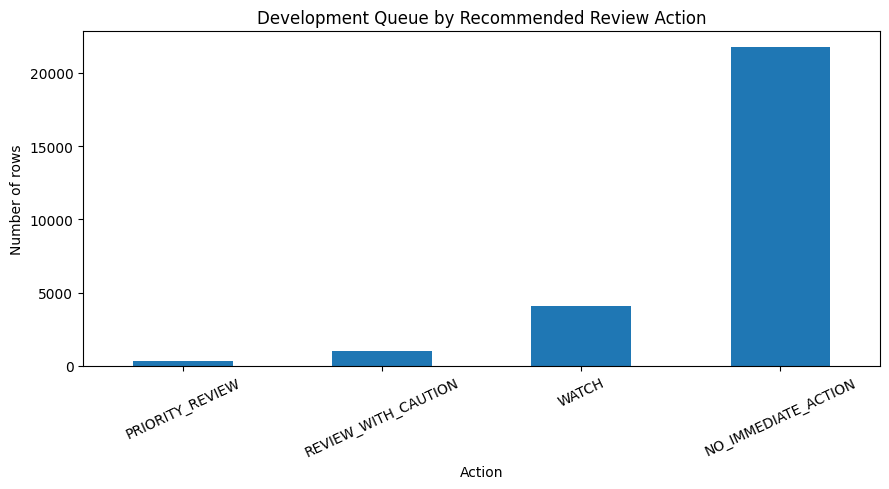

Action-distribution figure exported: /content/flyrank-machine-learning-internship/work/figures/w07_action_distribution.png


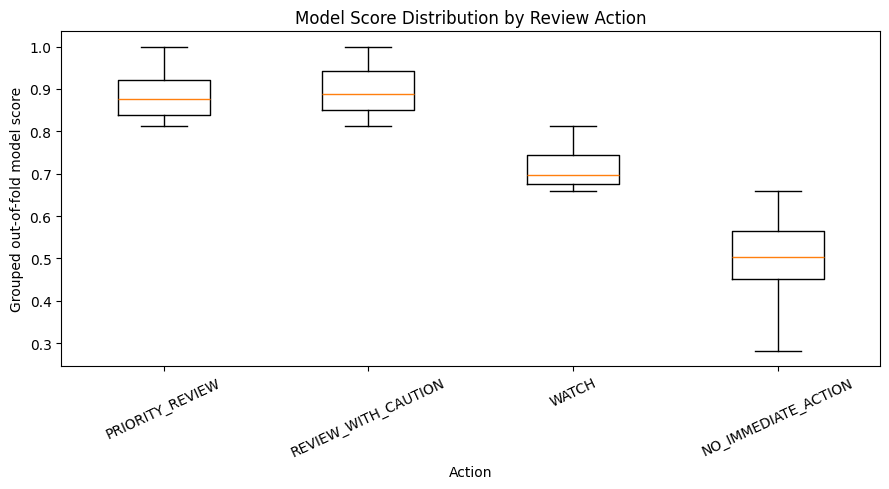

Score-by-action figure exported: /content/flyrank-machine-learning-internship/work/figures/w07_score_by_action.png

Export verification


,file,exists,size_bytes
0,work/outputs/w07_ranked_action_queue.csv,True,5312685
1,work/outputs/w07_action_playbook_metrics.json,True,1820
2,work/figures/w07_action_distribution.png,True,93725
3,work/figures/w07_score_by_action.png,True,99396



PASS: paper artifacts were exported successfully.
The queue CSV is generated locally and should remain out of git.
Commit the metrics JSON and reusable figures according to the repository rules.


In [7]:
# ============================================================
# Section 5 — Exports for the paper
# ============================================================
from pathlib import Path
import subprocess
import json
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Locate / clone repository
# ------------------------------------------------------------

REPO_URL = (
    "https://github.com/shaestasaleem/"
    "flyrank-machine-learning-internship.git"
)

PROJECT_ROOT = Path(
    "/content/flyrank-machine-learning-internship"
)

# Opening a notebook from GitHub in Colab does not
# automatically clone the full repository.
if not PROJECT_ROOT.exists():
    print("Repository not found in Colab. Cloning it now...")

    subprocess.run(
        [
            "git",
            "clone",
            REPO_URL,
            str(PROJECT_ROOT)
        ],
        check=True
    )

else:
    print("Repository already available.")


OUTPUT_DIR = PROJECT_ROOT / "work" / "outputs"
FIGURE_DIR = PROJECT_ROOT / "work" / "figures"

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("\nProject root:", PROJECT_ROOT)
print("Output directory:", OUTPUT_DIR)
print("Figure directory:", FIGURE_DIR)

assert (PROJECT_ROOT / "work").exists()

print("\nPASS: repository and work/ directory are ready.")



# ------------------------------------------------------------
# 1. Export ranked queue
# ------------------------------------------------------------
# Important:
# - hashed identifiers are retained so the internal queue
#   can map recommendations back to items
# - no client names, URLs, or private queries are exported
# - future outcome / label is NOT exported

queue_export_columns = [
    "rank",
    "client_hash_id",
    "content_hash_id",
    "action",
    "reason_codes",
    "model_score",
    "recent_impressions_7d",
    "recent_clicks_7d",
    "recent_ctr",
    "recent_avg_position",
    "pre_decision_click_change_7d",
    "ctr_vs_expected",
]

queue_export = ranked_queue[
    queue_export_columns
].copy()

QUEUE_PATH = (
    OUTPUT_DIR
    / "w07_ranked_action_queue.csv"
)

queue_export.to_csv(
    QUEUE_PATH,
    index=False
)

print(
    "\nQueue exported:",
    QUEUE_PATH
)

print(
    "Queue rows:",
    f"{len(queue_export):,}"
)


# ------------------------------------------------------------
# 2. Export metrics receipt
# ------------------------------------------------------------

action_counts = (
    ranked_queue["action"]
    .value_counts()
    .to_dict()
)

action_shares = (
    ranked_queue["action"]
    .value_counts(normalize=True)
    .to_dict()
)

metrics_receipt = {
    "assignment": "ML-10",
    "artifact": "Content Action Playbook",
    "development_period": "2026-03",
    "validation_design": (
        "5-fold GroupKFold by client_hash_id"
    ),
    "random_seed": RANDOM_SEED,

    "population": {
        "rows": int(len(ranked_queue)),
        "observed_future_decline_base_rate":
            float(oof[TARGET].mean()),
        "population_note": (
            "Evaluation population requires "
            "full-month March availability."
        )
    },

    "pooled_grouped_oof_metrics": {
        "precision_at_20": float(march_p20),
        "precision_at_50": float(march_p50),
        "roc_auc": float(march_auc),
        "note": (
            "These are pooled out-of-fold metrics, "
            "not averages of fold-level metrics."
        )
    },

    "queue_thresholds": {
        "top_5_percent_model_score":
            float(HIGH_SCORE_THRESHOLD),
        "top_20_percent_model_score":
            float(ELEVATED_SCORE_THRESHOLD),
        "low_exposure_q1_impressions":
            float(LOW_EXPOSURE_THRESHOLD),
        "high_exposure_q3_impressions":
            float(HIGH_EXPOSURE_THRESHOLD)
    },

    "action_counts": {
        str(k): int(v)
        for k, v in action_counts.items()
    },

    "action_shares": {
        str(k): float(v)
        for k, v in action_shares.items()
    },

    "review_workload": {
        "immediate_review_rows":
            int(len(review_pool)),
        "immediate_review_share":
            float(len(review_pool) / len(ranked_queue)),
        "low_exposure_caution_share":
            float(
                review_pool[
                    "has_low_exposure_caution"
                ].mean()
            ),
        "conflicting_signal_share":
            float(
                review_pool[
                    "has_conflicting_signals"
                ].mean()
            ),
        "recent_clicks_down_share":
            float(
                review_pool[
                    "recent_clicks_down"
                ].mean()
            )
    },

    "intended_use": (
        "Directional decision-support for "
        "prioritizing human editorial review."
    ),

    "not_supported": [
        "automatic content rewriting",
        "automatic publishing",
        "automatic deletion or redirect",
        "claiming a refresh is required",
        "claiming a refresh will improve performance"
    ],

    "sealed_period_status": (
        "June 2026 remains sealed and is not "
        "used in this playbook."
    )
}

METRICS_PATH = (
    OUTPUT_DIR
    / "w07_action_playbook_metrics.json"
)

with open(
    METRICS_PATH,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        metrics_receipt,
        f,
        indent=2
    )

print(
    "\nMetrics receipt exported:",
    METRICS_PATH
)


# ------------------------------------------------------------
# 3. Figure — action distribution
# ------------------------------------------------------------

action_order = [
    "PRIORITY_REVIEW",
    "REVIEW_WITH_CAUTION",
    "WATCH",
    "NO_IMMEDIATE_ACTION",
]

action_plot = (
    ranked_queue["action"]
    .value_counts()
    .reindex(action_order)
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(9, 5))

action_plot.plot(
    kind="bar",
    ax=ax
)

ax.set_title(
    "Development Queue by Recommended Review Action"
)

ax.set_xlabel("Action")
ax.set_ylabel("Number of rows")

ax.tick_params(
    axis="x",
    rotation=25
)

fig.tight_layout()

ACTION_FIG_PATH = (
    FIGURE_DIR
    / "w07_action_distribution.png"
)

fig.savefig(
    ACTION_FIG_PATH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print(
    "Action-distribution figure exported:",
    ACTION_FIG_PATH
)


# ------------------------------------------------------------
# 4. Figure — model score by action
# ------------------------------------------------------------

score_groups = [
    ranked_queue.loc[
        ranked_queue["action"] == action,
        "model_score"
    ].values
    for action in action_order
]

fig, ax = plt.subplots(figsize=(9, 5))

ax.boxplot(
    score_groups,
    tick_labels=action_order,
    showfliers=False
)

ax.set_title(
    "Model Score Distribution by Review Action"
)

ax.set_xlabel("Action")
ax.set_ylabel("Grouped out-of-fold model score")

ax.tick_params(
    axis="x",
    rotation=25
)

fig.tight_layout()

SCORE_FIG_PATH = (
    FIGURE_DIR
    / "w07_score_by_action.png"
)

fig.savefig(
    SCORE_FIG_PATH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print(
    "Score-by-action figure exported:",
    SCORE_FIG_PATH
)


# ------------------------------------------------------------
# 5. Verify exports
# ------------------------------------------------------------

expected_files = [
    QUEUE_PATH,
    METRICS_PATH,
    ACTION_FIG_PATH,
    SCORE_FIG_PATH,
]

export_check = pd.DataFrame([
    {
        "file": str(path.relative_to(PROJECT_ROOT)),
        "exists": path.exists(),
        "size_bytes":
            path.stat().st_size
            if path.exists()
            else 0
    }
    for path in expected_files
])

print("\nExport verification")
display(export_check)


assert export_check["exists"].all()

assert len(queue_export) == len(ranked_queue)

assert TARGET not in queue_export.columns

assert "future_clicks_7d" not in queue_export.columns

print(
    "\nPASS: paper artifacts were exported successfully."
)

print(
    "The queue CSV is generated locally and should "
    "remain out of git."
)

print(
    "Commit the metrics JSON and reusable figures "
    "according to the repository rules."
)


## Playbook conclusion

This playbook turns the validated model output into a practical but deliberately conservative review workflow.

From 27,186 March development rows, the action policy surfaces 1,360 rows (5.0%) for nearer human review. Of these, 328 are assigned to `PRIORITY_REVIEW` and 1,032 to `REVIEW_WITH_CAUTION`. Another 15% are placed in `WATCH`, while 80% receive `NO_IMMEDIATE_ACTION`.

The high share of low-exposure and conflicting-signal cases in the immediate-review pool reinforces the need for human context rather than automatic content changes.

The model therefore serves as a directional ranking and decision-support tool. It does not determine that content requires a refresh and does not establish that refreshing content will improve search performance.

The exported queue, metrics receipt, and figures provide the evidence that the next research-paper stage can build on.

## Self-check

- [x] Every section above is filled with markdown reasoning and supporting code.
- [x] The playbook converts grouped out-of-fold model scores into ranked human-review actions.
- [x] Every surfaced item receives transparent reason codes.
- [x] Action thresholds are described as operational heuristics, not learned truths.
- [x] The intended use is directional decision-support for human editorial review.
- [x] The model does not claim that a page definitely needs refreshing.
- [x] The model does not claim that refreshing content will improve performance.
- [x] Human-review rules are documented before any editorial action is taken.
- [x] Automatic rewriting, publishing, deletion, redirecting, and refresh decisions are explicitly prohibited.
- [x] Cost/value thinking is included by concentrating immediate review on 5% of the development population.
- [x] Monitoring references and revalidation/retrain triggers are documented.
- [x] Retraining remains a human-reviewed decision rather than an automatic trigger.
- [x] The ranked queue was exported to `work/outputs/w07_ranked_action_queue.csv`.
- [x] The metrics receipt was exported to `work/outputs/w07_action_playbook_metrics.json`.
- [x] Reusable figures were exported to `work/figures/`.
- [x] The operational queue does not contain the future outcome or future-click feature.
- [x] No client names, URLs, or private queries are displayed in notebook outputs.
- [x] Claims use careful language such as observed, measured, directional, ranks, flags, and decision-support.
- [x] March 2026 remains the development period.
- [x] June 2026 remains sealed.
- [x] Random seed 42 is recorded for reproducibility.